# GACC vs. bit-width — augmented points from a single x₀

All 100 JSON files in `results/volumes_mlp_walk1point/` come from augmented points
generated by the MCMC walk from a **single** original x₀ (MLP, FashionMNIST, seed 42).
Every point x' is inside Polytope #1 of x₀ but (typically) in a different
activation-pattern region of the q-model.

**Generalized accuracy (GACC)**:
$$\mathrm{GACC}(b) = \frac{\sum_{i} W^{\mathrm{both}}_i(b)}{\sum_{i} W^{\mathrm{correct}}_i(b)}$$
where the sums run over the chosen subset of augmented points,
$W^{\mathrm{correct}}_i(b)$ = mean width of P2 (q-model activation region) and
$W^{\mathrm{both}}_i(b)$ = mean width of P3 (P2 ∩ q-model classifies c).

We plot one GACC curve per subset size: **1, 10, 25, 50, 100 points**.

## Setup

In [8]:
%load_ext autoreload
%autoreload 2

import json
import math
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes


## Load results

In [34]:
MODEL = "mlp"  # "mlp" or "cnn"
RESULTS_DIR = ROOT / "results" / f"volumes_{MODEL}_walk1point"

def load_records(results_dir):
    recs = []
    for f in sorted(Path(results_dir).glob("volumes_sample*.json"),
                    key=lambda p: int(p.stem.split("sample")[1])):
        with open(f) as fh:
            recs.append(json.load(fh))
    return recs

records = load_records(RESULTS_DIR)
print(f"Found {len(records)} result files.")

bits_grid = sorted(int(b) for b in records[0]["widths_both"].keys())
print("Bits grid:", bits_grid)

Found 50 result files.
Bits grid: [4, 6, 8, 10, 12, 16]


In [35]:
records[13]

{'model_type': 'mlp',
 'sample_idx': 13,
 'model_path': '/lustre/fswork/projects/rech/aik/uhr51mx/ErrorVolumePolytopes/checkpoints/fashion_mlp_best.pth',
 'data_path': '/lustre/fswork/projects/rech/aik/uhr51mx/ErrorVolumePolytopes/data/fashionMNIST_augmented_mlp_seed42_walk.pt',
 'n_directions': 200,
 'n_directions_used': 200,
 'bits_grid': [4, 6, 8, 10, 12, 16],
 'width_base': 39.814268750805354,
 'widths_correct': {'4': 37.64992978577863,
  '6': 39.319531288172186,
  '8': 39.71532782012924,
  '10': 39.754492515436816,
  '12': 39.790469406385355,
  '16': 39.813944060846076},
 'widths_both': {'4': 37.649929785770844,
  '6': 39.3195312881681,
  '8': 39.7153278201256,
  '10': 39.75449251542587,
  '12': 39.790469406386016,
  '16': 39.81394406085113}}

## Compute GACC for each subset size

Subsets are the first N records sorted by `sample_idx` (i.e. indices 0…N-1).
NaN widths (empty polytope = q-model misclassifies) are treated as 0.

In [36]:
records[13]

{'model_type': 'mlp',
 'sample_idx': 13,
 'model_path': '/lustre/fswork/projects/rech/aik/uhr51mx/ErrorVolumePolytopes/checkpoints/fashion_mlp_best.pth',
 'data_path': '/lustre/fswork/projects/rech/aik/uhr51mx/ErrorVolumePolytopes/data/fashionMNIST_augmented_mlp_seed42_walk.pt',
 'n_directions': 200,
 'n_directions_used': 200,
 'bits_grid': [4, 6, 8, 10, 12, 16],
 'width_base': 39.814268750805354,
 'widths_correct': {'4': 37.64992978577863,
  '6': 39.319531288172186,
  '8': 39.71532782012924,
  '10': 39.754492515436816,
  '12': 39.790469406385355,
  '16': 39.813944060846076},
 'widths_both': {'4': 37.649929785770844,
  '6': 39.3195312881681,
  '8': 39.7153278201256,
  '10': 39.75449251542587,
  '12': 39.790469406386016,
  '16': 39.81394406085113}}

In [42]:
SUBSET_SIZES = [1, 10, 25, 50]

def safe(v):
    return 0.0 if (v is None or math.isnan(v)) else float(v)
#    return v

def gacc_for_subset(recs, bits_grid):
    """Returns dict {bits: GACC} for the given list of records."""
    sum_correct = {b: sum(safe(r["widths_correct"][str(b)]) for r in recs)
                   for b in bits_grid}
    sum_both    = {b: sum(safe(r["widths_both"][str(b)])    for r in recs)
                   for b in bits_grid}
    return {
        b: (sum_both[b] / sum_correct[b] if sum_correct[b] > 0 else float("nan"))
        for b in bits_grid
        }

gacc_by_n = {}
for n in SUBSET_SIZES:
    indexes = np.random.choice(len(records), size=n, replace=False)
    subset = [records[i] for i in indexes]
    gacc_by_n[n] = gacc_for_subset(subset, bits_grid)

# Pretty-print  (scientific notation so small deviations from 1 are visible)
print(f"{'N':>5}  " + "  ".join(f"   b={b:2d}   " for b in bits_grid))
print("-" * (7 + 12 * len(bits_grid)))
for n in SUBSET_SIZES:
    vals = "  ".join(f"{gacc_by_n[n][b]:.4e}" for b in bits_grid)
    print(f"{n:>5}   {vals}")

    N     b= 4        b= 6        b= 8        b=10        b=12        b=16   
-------------------------------------------------------------------------------
    1   1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00
   10   1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00
   25   1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00
   50   1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00


## Plot GACC curves

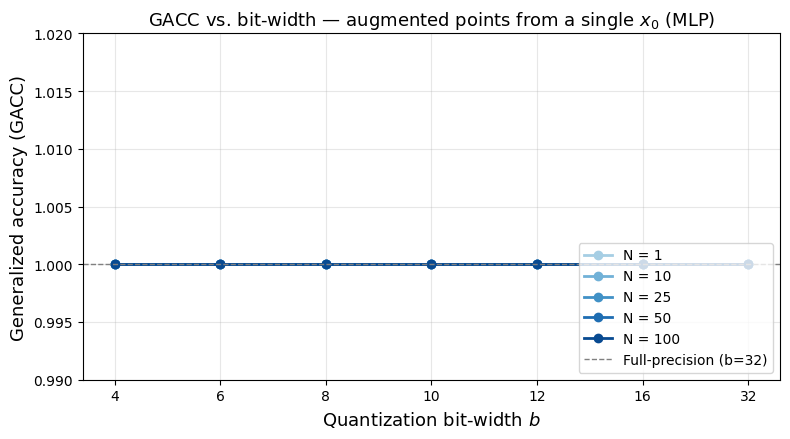

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/volumes_mlp_walk1point/gacc_vs_bits_1point.pdf


In [12]:
bits_arr = bits_grid + [32]
x_ticks  = list(range(len(bits_arr)))

# Colour map: lighter = fewer points, darker = more points
cmap   = plt.cm.Blues
colors = [cmap(0.35 + 0.55 * i / (len(SUBSET_SIZES) - 1))
          for i in range(len(SUBSET_SIZES))]

fig, ax = plt.subplots(figsize=(8, 4.5))

for color, n in zip(colors, SUBSET_SIZES):
    gacc_vals = [gacc_by_n[n][b] for b in bits_grid] + [1.0]   # append 32-bit reference
    ax.plot(x_ticks, gacc_vals,
            marker="o", linewidth=2, markersize=6,
            color=color, label=f"N = {n}")

ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Full-precision (b=32)")

ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel("Generalized accuracy (GACC)", fontsize=13)
ax.set_title(
    "GACC vs. bit-width — augmented points from a single $x_0$ (MLP)",
    fontsize=13,
)
ax.set_xticks(x_ticks)
ax.set_xticklabels(bits_arr)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3)

# Leave y-axis autoscaled — GACC could be very close to 1 or noticeably below
ymin = min(gacc_by_n[n][b] for n in SUBSET_SIZES for b in bits_grid)
ax.set_ylim(max(0.0, ymin - 0.01), 1.02)

plt.tight_layout()
out_path = RESULTS_DIR / "gacc_vs_bits_1point.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved to", out_path)

## Summary table — GACC and error

Error = 1 − GACC.

In [13]:
print(f"{'N':>5}  {'bits':>5}  {'GACC':>10}  {'error (1-GACC)':>16}")
print("-" * 45)
for n in SUBSET_SIZES:
    for b in bits_grid:
        g = gacc_by_n[n][b]
        print(f"{n:>5}  {b:>5}  {g:>10.6f}  {1-g:>16.6f}")
    print()

    N   bits        GACC    error (1-GACC)
---------------------------------------------
    1      4    1.000000         -0.000000
    1      6    1.000000          0.000000
    1      8    1.000000          0.000000
    1     10    1.000000          0.000000
    1     12    1.000000          0.000000
    1     16    1.000000          0.000000

   10      4    1.000000         -0.000000
   10      6    1.000000         -0.000000
   10      8    1.000000         -0.000000
   10     10    1.000000          0.000000
   10     12    1.000000          0.000000
   10     16    1.000000          0.000000

   25      4    1.000000         -0.000000
   25      6    1.000000         -0.000000
   25      8    1.000000         -0.000000
   25     10    1.000000          0.000000
   25     12    1.000000          0.000000
   25     16    1.000000          0.000000

   50      4    1.000000         -0.000000
   50      6    1.000000         -0.000000
   50      8    1.000000         -0.000000
   50

## Inspect individual widths for sample 0 (= first walk representative)

Quick sanity check: compare P1, P2, P3 mean widths for the first augmented point.

In [14]:
r0 = records[0]
print(f"sample_idx = {r0['sample_idx']}")
print(f"  width_base   (P1) = {r0['width_base']:.4f}")
print()
print(f"  {'bits':>5}  {'W_correct (P2)':>16}  {'W_both (P3)':>13}  {'P3/P2':>8}  {'P2/P1':>8}")
print("  " + "-" * 60)
for b in bits_grid:
    wc = safe(r0["widths_correct"][str(b)])
    wb = safe(r0["widths_both"][str(b)])
    ratio_32 = wb / wc if wc > 0 else float("nan")
    ratio_p1 = wc / r0["width_base"] if r0["width_base"] > 0 else float("nan")
    print(f"  {b:>5}  {wc:>16.4f}  {wb:>13.4f}  {ratio_32:>8.6f}  {ratio_p1:>8.6f}")

sample_idx = 0
  width_base   (P1) = 39.7636

   bits    W_correct (P2)    W_both (P3)     P3/P2     P2/P1
  ------------------------------------------------------------
      4           37.5746        37.5746  1.000000  0.944949
      6           39.3043        39.3043  1.000000  0.988449
      8           39.6608        39.6608  1.000000  0.997416
     10           39.7097        39.7097  1.000000  0.998645
     12           39.7577        39.7577  1.000000  0.999851
     16           39.7633        39.7633  1.000000  0.999992
